# Advanced Trading System: ML Forecasting + Technical Signals

## System Architecture
1. **ML Forecasting Layer**: Predicts trend direction (bullish/bearish) for multiple time horizons
2. **Technical Signal Layer**: Generates precise BUY/SELL/HOLD signals based on indicators
3. **Combined Strategy**: Only trade when both layers align

### Trading Logic
- **BUY**: Forecast predicts uptrend AND technical indicators show bullish entry
- **SELL**: Forecast predicts downtrend OR technical indicators show bearish signals
- **HOLD**: Conflicting signals or neutral conditions

## Setup & Installation

In [1]:
# Install required packages (uncomment to run)
# %pip install -q yfinance ta lightgbm scikit-learn matplotlib seaborn

In [2]:
import warnings
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Technical indicators
from ta.trend import SMAIndicator, EMAIndicator, MACD, ADXIndicator
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful")
print(f"LightGBM available: {LIGHTGBM_AVAILABLE}")

✅ All imports successful
LightGBM available: True


## Configuration

In [3]:
@dataclass
class TradingConfig:
    """Configuration for the trading system"""
    # Stock settings
    ticker: str = "SMRA.JK"
    start_date: str = "2020-01-01"
    
    # Forecast settings
    forecast_horizons: List[int] = None  # [1, 5, 21] days
    train_test_split: float = 0.8
    
    # Technical indicator settings
    sma_windows: List[int] = None
    ema_windows: List[int] = None
    rsi_window: int = 14
    macd_fast: int = 12
    macd_slow: int = 26
    macd_signal: int = 9
    bb_window: int = 20
    bb_dev: int = 2
    adx_window: int = 14
    
    # Trading signal thresholds
    rsi_oversold: int = 30
    rsi_overbought: int = 70
    rsi_neutral_low: int = 45
    rsi_neutral_high: int = 50
    adx_trend_threshold: int = 20
    
    # Macro indicators
    macro_tickers: List[str] = None
    
    def __post_init__(self):
        if self.forecast_horizons is None:
            self.forecast_horizons = [1, 5, 21]  # 1 day, 1 week, 1 month
        if self.sma_windows is None:
            self.sma_windows = [20, 50, 100, 200]
        if self.ema_windows is None:
            self.ema_windows = [12, 20, 26, 50]
        if self.macro_tickers is None:
            self.macro_tickers = [
                "^JKSE",      # Jakarta Composite
                "^GSPC",      # S&P 500
                "CL=F",       # Crude Oil
                "USDIDR=X",   # USD/IDR
                "^VIX"        # Volatility
            ]

config = TradingConfig()
print(f"📊 Trading System Config:")
print(f"   Ticker: {config.ticker}")
print(f"   Forecast horizons: {config.forecast_horizons} days")
print(f"   Start date: {config.start_date}")

📊 Trading System Config:
   Ticker: SMRA.JK
   Forecast horizons: [1, 5, 21] days
   Start date: 2020-01-01


## 1. Data Loading

In [4]:
class DataLoader:
    """Handles data downloading with proper column handling"""
    
    @staticmethod
    def s1d(obj, name=None):
        """Force 1-D float series (handles Series/DataFrame/MultiIndex)"""
        if isinstance(obj, pd.DataFrame):
            s = obj.iloc[:, 0]
        else:
            s = pd.Series(np.ravel(obj.values), index=obj.index, 
                         name=name or getattr(obj, "name", None))
        return pd.to_numeric(s, errors="coerce")
    
    @staticmethod
    def download_stock(ticker: str, start_date: str) -> pd.DataFrame:
        """Download stock data and return clean DataFrame"""
        try:
            print(f"📥 Downloading {ticker}...")
            data = yf.download(ticker, start=start_date, auto_adjust=False, progress=False)
            
            if data.empty:
                raise ValueError(f"No data for {ticker}")
            
            # Handle multi-level columns
            if isinstance(data.columns, pd.MultiIndex):
                df = pd.DataFrame({
                    'Open': DataLoader.s1d(data['Open'][ticker], 'Open'),
                    'High': DataLoader.s1d(data['High'][ticker], 'High'),
                    'Low': DataLoader.s1d(data['Low'][ticker], 'Low'),
                    'Close': DataLoader.s1d(data['Close'][ticker], 'Close'),
                    'Volume': DataLoader.s1d(data['Volume'][ticker], 'Volume'),
                    'Adj Close': DataLoader.s1d(data['Adj Close'][ticker], 'Adj Close')
                })
            else:
                df = pd.DataFrame({
                    'Open': DataLoader.s1d(data['Open'], 'Open'),
                    'High': DataLoader.s1d(data['High'], 'High'),
                    'Low': DataLoader.s1d(data['Low'], 'Low'),
                    'Close': DataLoader.s1d(data['Close'], 'Close'),
                    'Volume': DataLoader.s1d(data['Volume'], 'Volume'),
                    'Adj Close': DataLoader.s1d(data['Adj Close'], 'Adj Close')
                })
            
            df = df.dropna()
            print(f"✅ {ticker}: {len(df)} rows ({df.index[0].date()} to {df.index[-1].date()})")
            return df
            
        except Exception as e:
            print(f"❌ Error: {e}")
            return pd.DataFrame()
    
    @staticmethod
    def download_macro(tickers: List[str], start_date: str) -> Dict[str, pd.DataFrame]:
        """Download macro indicators"""
        macro_data = {}
        for ticker in tickers:
            data = DataLoader.download_stock(ticker, start_date)
            if not data.empty:
                macro_data[ticker] = data
        return macro_data

# Load data
loader = DataLoader()
df_main = loader.download_stock(config.ticker, config.start_date)
macro_data = loader.download_macro(config.macro_tickers, config.start_date)

print(f"\n📊 Main stock: {df_main.shape}")
print(f"📊 Macro indicators: {len(macro_data)}")
print(f"\nFirst few rows:")
print(df_main.head())

📥 Downloading SMRA.JK...
✅ SMRA.JK: 1474 rows (2020-01-02 to 2026-02-10)
📥 Downloading ^JKSE...
✅ ^JKSE: 1474 rows (2020-01-02 to 2026-02-10)
📥 Downloading ^GSPC...
✅ ^GSPC: 1534 rows (2020-01-02 to 2026-02-09)
📥 Downloading CL=F...
✅ CL=F: 1537 rows (2020-01-02 to 2026-02-10)
📥 Downloading USDIDR=X...
✅ USDIDR=X: 1590 rows (2020-01-01 to 2026-02-10)
📥 Downloading ^VIX...
✅ ^VIX: 1534 rows (2020-01-02 to 2026-02-09)

📊 Main stock: (1474, 6)
📊 Macro indicators: 5

First few rows:
                  Open         High         Low       Close    Volume  \
Date                                                                    
2020-01-02  978.659424   978.659424  964.124878  968.969727   6708981   
2020-01-03  968.969727  1007.728516  959.280029  988.349121  26091321   
2020-01-06  983.504272   993.193970  959.280029  959.280029  11252260   
2020-01-07  968.969727   968.969727  939.900635  944.745483  14359788   
2020-01-08  939.900635   939.900635  910.831543  925.366089  16921684   

    

## 2. Feature Engineering for ML

In [5]:
class MLFeatureEngineer:
    """Creates features for machine learning models"""
    
    def __init__(self, config: TradingConfig):
        self.config = config
    
    def create_features(self, df: pd.DataFrame, macro_data: Dict[str, pd.DataFrame]) -> pd.DataFrame:
        """Create comprehensive feature set for ML"""
        df = df.copy()
        
        # Price features
        df['returns'] = df['Close'].pct_change()
        df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['hl_range'] = (df['High'] - df['Low']) / df['Close']
        df['oc_change'] = (df['Close'] - df['Open']) / df['Open']
        
        # Moving averages
        for window in self.config.sma_windows:
            df[f'sma_{window}'] = df['Close'].rolling(window).mean()
            df[f'close_to_sma_{window}'] = df['Close'] / df[f'sma_{window}'] - 1
        
        for window in self.config.ema_windows:
            df[f'ema_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()
        
        # Technical indicators
        df['rsi'] = RSIIndicator(df['Close'], window=self.config.rsi_window).rsi()
        
        macd = MACD(df['Close'], window_slow=self.config.macd_slow, 
                   window_fast=self.config.macd_fast, window_sign=self.config.macd_signal)
        df['macd'] = macd.macd()
        df['macd_signal'] = macd.macd_signal()
        df['macd_diff'] = macd.macd_diff()
        
        bb = BollingerBands(df['Close'], window=self.config.bb_window, window_dev=self.config.bb_dev)
        df['bb_middle'] = bb.bollinger_mavg()
        df['bb_upper'] = bb.bollinger_hband()
        df['bb_lower'] = bb.bollinger_lband()
        df['bb_width'] = bb.bollinger_wband()
        df['bb_position'] = (df['Close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
        
        adx = ADXIndicator(df['High'], df['Low'], df['Close'], window=self.config.adx_window)
        df['adx'] = adx.adx()
        df['adx_pos'] = adx.adx_pos()
        df['adx_neg'] = adx.adx_neg()
        
        df['atr'] = AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
        
        obv = OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume()
        df['obv'] = obv
        df['obv_change'] = obv.diff()
        df['obv_ema'] = obv.ewm(span=20, adjust=False).mean()
        
        # Volume features
        df['volume_sma'] = df['Volume'].rolling(20).mean()
        df['volume_ratio'] = df['Volume'] / df['volume_sma']
        
        # Lagged features
        for lag in [1, 5, 10, 21]:
            df[f'returns_lag_{lag}'] = df['returns'].shift(lag)
            df[f'close_lag_{lag}'] = df['Close'].shift(lag)
        
        # Rolling statistics
        for window in [5, 10, 21]:
            df[f'volatility_{window}'] = df['returns'].rolling(window).std()
            df[f'returns_mean_{window}'] = df['returns'].rolling(window).mean()
        
        # Add macro features
        for ticker, macro_df in macro_data.items():
            clean_name = ticker.replace("^", "").replace("=", "_").replace("-", "_").replace(".", "_")
            macro_close = macro_df[['Close']].copy()
            macro_close.columns = [f'macro_{clean_name}']
            df = df.join(macro_close, how='left')
            df[f'macro_{clean_name}'].fillna(method='ffill', inplace=True)
            df[f'macro_{clean_name}_returns'] = df[f'macro_{clean_name}'].pct_change()
        
        return df
    
    def create_targets(self, df: pd.DataFrame) -> pd.DataFrame:
        """Create target variables for forecasting"""
        df = df.copy()
        
        for h in self.config.forecast_horizons:
            # Future return
            df[f'target_return_{h}'] = df['Close'].pct_change(h).shift(-h)
            
            # Future price
            df[f'target_price_{h}'] = df['Close'].shift(-h)
            
            # Direction (1=up, 0=down)
            df[f'target_direction_{h}'] = (df[f'target_return_{h}'] > 0).astype(int)
        
        return df

# Create ML features
print("🔧 Creating ML features...")
ml_engineer = MLFeatureEngineer(config)
df_ml = ml_engineer.create_features(df_main, macro_data)
df_ml = ml_engineer.create_targets(df_ml)
df_ml_clean = df_ml.dropna()

print(f"✅ ML features created: {df_ml_clean.shape}")
print(f"📅 Date range: {df_ml_clean.index[0].date()} to {df_ml_clean.index[-1].date()}")

🔧 Creating ML features...
✅ ML features created: (1254, 73)
📅 Date range: 2020-10-23 to 2026-01-09


## 3. ML Forecasting Models

In [6]:
class ForecastingEngine:
    """ML models for trend forecasting"""
    
    def __init__(self, horizon: int):
        self.horizon = horizon
        self.models = {}
        self.scaler = StandardScaler()
        self.feature_names = []
    
    def _get_models(self):
        models = {
            'rf': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
            'gbr': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42),
            'ridge': Ridge(alpha=1.0)
        }
        if LIGHTGBM_AVAILABLE:
            models['lgbm'] = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
        return models
    
    def prepare_data(self, df: pd.DataFrame):
        """Prepare features and targets"""
        target_col = f'target_price_{self.horizon}'
        exclude_cols = [col for col in df.columns if col.startswith('target_')]
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        numeric_df = df[feature_cols].select_dtypes(include=[np.number])
        
        X = numeric_df.values
        y = df[target_col].values
        self.feature_names = numeric_df.columns.tolist()
        
        return X, y
    
    def train(self, X_train, y_train):
        """Train ensemble models"""
        X_train_scaled = self.scaler.fit_transform(X_train)
        self.models = self._get_models()
        
        for name, model in self.models.items():
            print(f"  Training {name}...", end=" ")
            model.fit(X_train_scaled, y_train)
            print("✓")
    
    def predict(self, X):
        """Ensemble prediction"""
        X_scaled = self.scaler.transform(X)
        predictions = [model.predict(X_scaled) for model in self.models.values()]
        return np.mean(predictions, axis=0)

# Train forecasting models
forecasters = {}
predictions = {}

split_idx = int(len(df_ml_clean) * config.train_test_split)

for horizon in config.forecast_horizons:
    print(f"\n{'='*60}")
    print(f"🎯 Training forecast model for H={horizon} days")
    print(f"{'='*60}")
    
    forecaster = ForecastingEngine(horizon)
    X, y = forecaster.prepare_data(df_ml_clean)
    
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
    
    forecaster.train(X_train, y_train)
    
    # Predict on full dataset
    y_pred = forecaster.predict(X)
    
    forecasters[horizon] = forecaster
    predictions[horizon] = y_pred
    
    # Add predictions to dataframe
    df_ml_clean[f'forecast_{horizon}'] = y_pred
    df_ml_clean[f'forecast_direction_{horizon}'] = (y_pred > df_ml_clean['Close'].values).astype(int)

print(f"\n✅ All forecasting models trained!")


🎯 Training forecast model for H=1 days
Train: 1003, Test: 251
  Training rf... ✓
  Training gbr... ✓
  Training ridge... ✓
  Training lgbm... ✓

🎯 Training forecast model for H=5 days
Train: 1003, Test: 251
  Training rf... ✓
  Training gbr... ✓
  Training ridge... ✓
  Training lgbm... ✓

🎯 Training forecast model for H=21 days
Train: 1003, Test: 251
  Training rf... ✓
  Training gbr... ✓
  Training ridge... ✓
  Training lgbm... ✓

✅ All forecasting models trained!


## 4. Technical Signal Generation

In [7]:
class TechnicalSignalGenerator:
    """Generates BUY/SELL/HOLD signals from technical indicators"""
    
    def __init__(self, config: TradingConfig):
        self.config = config
    
    def generate_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        """Generate trading signals based on technical indicators"""
        df = df.copy()
        
        # MACD crossover signals
        macd_bullish = (df['macd'].shift(1) < df['macd_signal'].shift(1)) & (df['macd'] > df['macd_signal'])
        macd_bearish = (df['macd'].shift(1) > df['macd_signal'].shift(1)) & (df['macd'] < df['macd_signal'])
        
        # Composite BUY conditions
        buy_conditions = (
            (df['sma_20'] > df['sma_50']) &  # Uptrend
            macd_bullish &  # MACD crossover up
            (df['rsi'] > self.config.rsi_neutral_high) &  # RSI bullish
            (df['rsi'] < self.config.rsi_overbought) &  # Not overbought
            (df['adx'] > self.config.adx_trend_threshold) &  # Strong trend
            (df['obv_change'] > 0) &  # Volume confirming
            (df['Close'] > df['bb_middle'])  # Above BB middle
        )
        
        # Composite SELL conditions
        sell_conditions = (
            (df['sma_20'] < df['sma_50']) |  # Downtrend
            macd_bearish |  # MACD crossover down
            (df['rsi'] < self.config.rsi_neutral_low) |  # RSI bearish
            (df['Close'] < df['bb_middle'])  # Below BB middle
        )
        
        # Strong BUY (additional conditions)
        strong_buy = (
            buy_conditions &
            (df['rsi'] > 55) &
            (df['adx'] > 25) &
            (df['Close'] > df['bb_upper'] * 0.98)
        )
        
        # Strong SELL (exit conditions)
        strong_sell = (
            (df['rsi'] > self.config.rsi_overbought) |
            (df['Close'] < df['bb_lower']) |
            (df['rsi'] < self.config.rsi_oversold)
        )
        
        # Assign signals
        df['technical_signal'] = 'HOLD'
        df.loc[buy_conditions, 'technical_signal'] = 'BUY'
        df.loc[sell_conditions, 'technical_signal'] = 'SELL'
        df.loc[strong_buy, 'technical_signal'] = 'STRONG_BUY'
        df.loc[strong_sell, 'technical_signal'] = 'STRONG_SELL'
        
        # Signal strength (0-100)
        df['signal_strength'] = 50  # Neutral
        
        # Bullish strength
        bullish_score = (
            ((df['sma_20'] > df['sma_50']).astype(int) * 15) +
            (macd_bullish.astype(int) * 20) +
            (((df['rsi'] - 50) / 50 * 15).clip(0, 15)) +
            (((df['adx'] - 20) / 30 * 15).clip(0, 15)) +
            ((df['obv_change'] > 0).astype(int) * 10) +
            ((df['Close'] > df['bb_middle']).astype(int) * 10)
        )
        
        # Bearish strength
        bearish_score = (
            ((df['sma_20'] < df['sma_50']).astype(int) * -15) +
            (macd_bearish.astype(int) * -20) +
            (((50 - df['rsi']) / 50 * 15).clip(0, 15) * -1) +
            ((df['Close'] < df['bb_middle']).astype(int) * -10)
        )
        
        df['signal_strength'] = (50 + bullish_score + bearish_score).clip(0, 100)
        
        return df

# Generate technical signals
print("🔧 Generating technical signals...")
signal_gen = TechnicalSignalGenerator(config)
df_signals = signal_gen.generate_signals(df_ml_clean)

print(f"✅ Technical signals generated")
print(f"\nSignal distribution:")
print(df_signals['technical_signal'].value_counts())

🔧 Generating technical signals...
✅ Technical signals generated

Signal distribution:
technical_signal
SELL           864
HOLD           250
STRONG_SELL    134
BUY              4
STRONG_BUY       2
Name: count, dtype: int64


## 5. Combined Trading Strategy

In [8]:
class CombinedTradingStrategy:
    """Combines ML forecasts with technical signals"""
    
    def __init__(self, config: TradingConfig):
        self.config = config
    
    def combine_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        """Combine forecast and technical signals"""
        df = df.copy()
        
        # Use shortest horizon for immediate trading decisions
        short_horizon = min(self.config.forecast_horizons)
        
        # Use medium horizon for trend confirmation
        medium_horizon = sorted(self.config.forecast_horizons)[len(self.config.forecast_horizons)//2] if len(self.config.forecast_horizons) > 1 else short_horizon
        
        # ML forecast signals
        df['ml_bullish_short'] = df[f'forecast_direction_{short_horizon}'] == 1
        df['ml_bullish_medium'] = df[f'forecast_direction_{medium_horizon}'] == 1
        
        # Combined logic
        df['final_signal'] = 'HOLD'
        
        # STRONG BUY: ML predicts up AND technical shows strong buy
        strong_buy = (
            df['ml_bullish_short'] &
            df['ml_bullish_medium'] &
            (df['technical_signal'].isin(['BUY', 'STRONG_BUY'])) &
            (df['signal_strength'] > 65)
        )
        
        # BUY: ML predicts up OR strong technical signal
        buy = (
            (df['ml_bullish_short'] & (df['technical_signal'] == 'BUY')) |
            (df['ml_bullish_medium'] & (df['technical_signal'] == 'STRONG_BUY'))
        ) & ~strong_buy
        
        # SELL: ML predicts down OR technical shows sell
        sell = (
            (~df['ml_bullish_short'] & (df['technical_signal'].isin(['SELL', 'STRONG_SELL']))) |
            (df['technical_signal'] == 'STRONG_SELL') |
            (df['signal_strength'] < 35)
        )
        
        df.loc[buy, 'final_signal'] = 'BUY'
        df.loc[strong_buy, 'final_signal'] = 'STRONG_BUY'
        df.loc[sell, 'final_signal'] = 'SELL'
        
        # Confidence score (0-100)
        ml_confidence = 50
        for h in self.config.forecast_horizons:
            forecast_return = (df[f'forecast_{h}'] - df['Close']) / df['Close']
            ml_confidence += abs(forecast_return) * 100 / len(self.config.forecast_horizons)
        
        df['confidence'] = ((ml_confidence + df['signal_strength']) / 2).clip(0, 100)
        
        return df

# Create combined strategy
print("🎯 Combining ML forecasts with technical signals...")
strategy = CombinedTradingStrategy(config)
df_final = strategy.combine_signals(df_signals)

print(f"✅ Combined strategy created")
print(f"\nFinal signal distribution:")
print(df_final['final_signal'].value_counts())
print(f"\nMean confidence: {df_final['confidence'].mean():.1f}%")

🎯 Combining ML forecasts with technical signals...
✅ Combined strategy created

Final signal distribution:
final_signal
SELL          684
HOLD          567
STRONG_BUY      2
BUY             1
Name: count, dtype: int64

Mean confidence: 56.4%


## 6. Visualization & Analysis


💾 Chart saved as 'combined_trading_system.png'


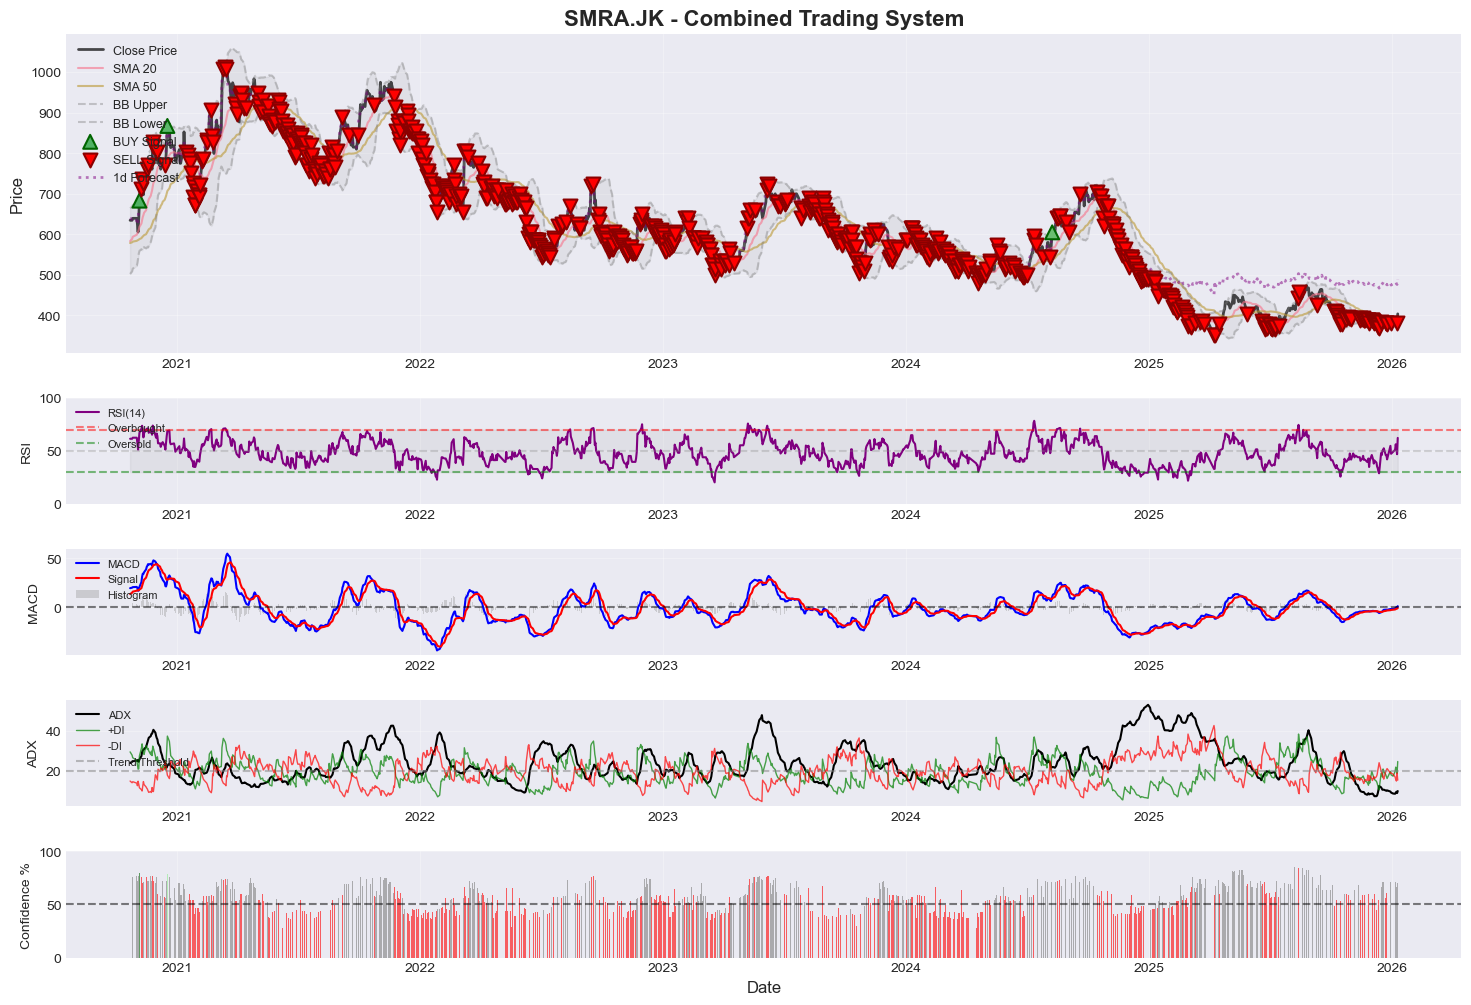

In [9]:
# Create comprehensive trading chart
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(5, 1, hspace=0.3, height_ratios=[3, 1, 1, 1, 1])

# 1. Price chart with signals
ax1 = fig.add_subplot(gs[0])
ax1.plot(df_final.index, df_final['Close'], label='Close Price', linewidth=2, alpha=0.7, color='black')
ax1.plot(df_final.index, df_final['sma_20'], label='SMA 20', alpha=0.6, linewidth=1.5)
ax1.plot(df_final.index, df_final['sma_50'], label='SMA 50', alpha=0.6, linewidth=1.5)
ax1.plot(df_final.index, df_final['bb_upper'], label='BB Upper', alpha=0.4, linestyle='--', color='gray')
ax1.plot(df_final.index, df_final['bb_lower'], label='BB Lower', alpha=0.4, linestyle='--', color='gray')
ax1.fill_between(df_final.index, df_final['bb_lower'], df_final['bb_upper'], alpha=0.1, color='gray')

# Plot signals
buy_signals = df_final[df_final['final_signal'].isin(['BUY', 'STRONG_BUY'])]
sell_signals = df_final[df_final['final_signal'] == 'SELL']

ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', s=100, 
           c=buy_signals['confidence'], cmap='Greens', edgecolors='darkgreen', 
           linewidths=1.5, label='BUY Signal', zorder=5, vmin=50, vmax=100)
ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', s=100, 
           c='red', edgecolors='darkred', linewidths=1.5, label='SELL Signal', zorder=5)

# Plot forecast
short_h = min(config.forecast_horizons)
ax1.plot(df_final.index, df_final[f'forecast_{short_h}'], 
        label=f'{short_h}d Forecast', alpha=0.5, linestyle=':', linewidth=2, color='purple')

ax1.set_title(f'{config.ticker} - Combined Trading System', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. RSI
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(df_final.index, df_final['rsi'], label='RSI(14)', color='purple', linewidth=1.5)
ax2.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought')
ax2.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold')
ax2.axhline(50, linestyle='--', alpha=0.3, color='gray')
ax2.fill_between(df_final.index, 30, 70, alpha=0.1, color='gray')
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_ylim([0, 100])
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. MACD
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(df_final.index, df_final['macd'], label='MACD', color='blue', linewidth=1.5)
ax3.plot(df_final.index, df_final['macd_signal'], label='Signal', color='red', linewidth=1.5)
ax3.bar(df_final.index, df_final['macd_diff'], label='Histogram', alpha=0.3, color='gray')
ax3.axhline(0, linestyle='--', alpha=0.5, color='black')
ax3.set_ylabel('MACD', fontsize=10)
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. ADX
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.plot(df_final.index, df_final['adx'], label='ADX', color='black', linewidth=1.5)
ax4.plot(df_final.index, df_final['adx_pos'], label='+DI', color='green', linewidth=1, alpha=0.7)
ax4.plot(df_final.index, df_final['adx_neg'], label='-DI', color='red', linewidth=1, alpha=0.7)
ax4.axhline(20, linestyle='--', alpha=0.5, color='gray', label='Trend Threshold')
ax4.set_ylabel('ADX', fontsize=10)
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Signal Confidence
ax5 = fig.add_subplot(gs[4], sharex=ax1)
colors = df_final['final_signal'].map({
    'STRONG_BUY': 'darkgreen', 'BUY': 'lightgreen', 
    'HOLD': 'gray', 'SELL': 'red'
})
ax5.bar(df_final.index, df_final['confidence'], color=colors, alpha=0.6)
ax5.axhline(50, linestyle='--', alpha=0.5, color='black')
ax5.set_ylabel('Confidence %', fontsize=10)
ax5.set_xlabel('Date', fontsize=12)
ax5.set_ylim([0, 100])
ax5.grid(True, alpha=0.3)

plt.tight_layout()

try:
    plt.savefig('combined_trading_system.png', dpi=150, bbox_inches='tight')
    print("\n💾 Chart saved as 'combined_trading_system.png'")
except Exception as e:
    print(f"\n⚠️ Could not save chart: {e}")

plt.show()

## 7. Recent Signals & Recommendations

In [10]:
# Get recent signals
recent_days = 30
df_recent = df_final.tail(recent_days)

print(f"\n{'='*80}")
print(f"RECENT TRADING SIGNALS (Last {recent_days} days)")
print(f"{'='*80}\n")

# Latest position
latest = df_final.iloc[-1]
print(f"📅 Latest Date: {df_final.index[-1].date()}")
print(f"💰 Current Price: {latest['Close']:.2f}")
print(f"🎯 Final Signal: {latest['final_signal']}")
print(f"📊 Confidence: {latest['confidence']:.1f}%")
print(f"📈 Technical Signal: {latest['technical_signal']}")
print(f"🔮 Signal Strength: {latest['signal_strength']:.1f}%\n")

# Forecast summary
print("🔮 ML Forecasts:")
for h in config.forecast_horizons:
    forecast_price = latest[f'forecast_{h}']
    forecast_return = (forecast_price - latest['Close']) / latest['Close'] * 100
    direction = "📈 UP" if forecast_return > 0 else "📉 DOWN"
    print(f"   {h:2d} days: {forecast_price:.2f} ({forecast_return:+.2f}%) {direction}")

# Technical indicator summary
print(f"\n📊 Technical Indicators:")
print(f"   RSI: {latest['rsi']:.1f} {'(Overbought)' if latest['rsi'] > 70 else '(Oversold)' if latest['rsi'] < 30 else ''}")
print(f"   MACD: {latest['macd']:.2f} (Signal: {latest['macd_signal']:.2f})")
print(f"   ADX: {latest['adx']:.1f} {'(Strong Trend)' if latest['adx'] > 25 else '(Weak Trend)' if latest['adx'] < 20 else '(Moderate Trend)'}")
print(f"   BB Position: {latest['bb_position']:.2f} {'(Above Upper)' if latest['bb_position'] > 1 else '(Below Lower)' if latest['bb_position'] < 0 else ''}")

# Recent actionable signals
print(f"\n📋 Recent Actionable Signals:")
actionable = df_recent[df_recent['final_signal'].isin(['BUY', 'STRONG_BUY', 'SELL'])]

if len(actionable) > 0:
    signal_summary = actionable[['final_signal', 'Close', 'confidence', 'rsi', 'adx']].tail(10)
    signal_summary.columns = ['Signal', 'Price', 'Confidence', 'RSI', 'ADX']
    print(signal_summary.to_string())
else:
    print("   No actionable signals in recent period.")

# Trading recommendation
print(f"\n{'='*80}")
print("💡 TRADING RECOMMENDATION")
print(f"{'='*80}\n")

if latest['final_signal'] in ['BUY', 'STRONG_BUY']:
    print("✅ RECOMMENDATION: CONSIDER BUYING")
    print(f"   - Both ML forecast and technical indicators suggest upward movement")
    print(f"   - Confidence level: {latest['confidence']:.1f}%")
    if latest['final_signal'] == 'STRONG_BUY':
        print(f"   - This is a STRONG BUY signal with high conviction")
elif latest['final_signal'] == 'SELL':
    print("❌ RECOMMENDATION: CONSIDER SELLING or AVOID ENTRY")
    print(f"   - Indicators suggest downward pressure or weakening momentum")
    print(f"   - Confidence level: {latest['confidence']:.1f}%")
else:
    print("⏸️ RECOMMENDATION: HOLD / WAIT")
    print(f"   - Mixed signals or neutral conditions")
    print(f"   - Wait for clearer confirmation before entering")

print(f"\n⚠️ RISK DISCLAIMER: This is an automated analysis tool, not financial advice.")
print(f"   Always conduct your own research and consider your risk tolerance.")


RECENT TRADING SIGNALS (Last 30 days)

📅 Latest Date: 2026-01-09
💰 Current Price: 404.00
🎯 Final Signal: HOLD
📊 Confidence: 70.2%
📈 Technical Signal: SELL
🔮 Signal Strength: 58.7%

🔮 ML Forecasts:
    1 days: 489.45 (+21.15%) 📈 UP
    5 days: 541.22 (+33.97%) 📈 UP
   21 days: 565.83 (+40.06%) 📈 UP

📊 Technical Indicators:
   RSI: 62.2 
   MACD: 1.16 (Signal: -0.77)
   ADX: 10.0 (Weak Trend)
   BB Position: 1.21 (Above Upper)

📋 Recent Actionable Signals:
           Signal  Price  Confidence        RSI        ADX
Date                                                      
2025-12-09   SELL  378.0   54.543700  35.300038   7.860135
2025-12-10   SELL  376.0   54.443259  33.589785   8.929651
2025-12-11   SELL  372.0   54.454408  30.415839  10.529735
2025-12-12   SELL  370.0   54.316727  28.943209  12.535533
2025-12-15   SELL  384.0   60.737368  47.943221  11.872077
2025-12-22   SELL  382.0   55.916539  45.980850  10.261655
2025-12-23   SELL  382.0   60.838061  45.980850  10.157953
2025-12-2

## 8. Strategy Performance Analysis


BACKTEST RESULTS (Test Period)

Initial Capital: $10,000.00
Final Capital: $10,000.00

📊 Strategy Return: 0.00%
📊 Buy & Hold Return: -20.78%
📊 Outperformance: 20.78%

🔄 Number of Trades: 0

💾 Performance chart saved as 'strategy_performance.png'


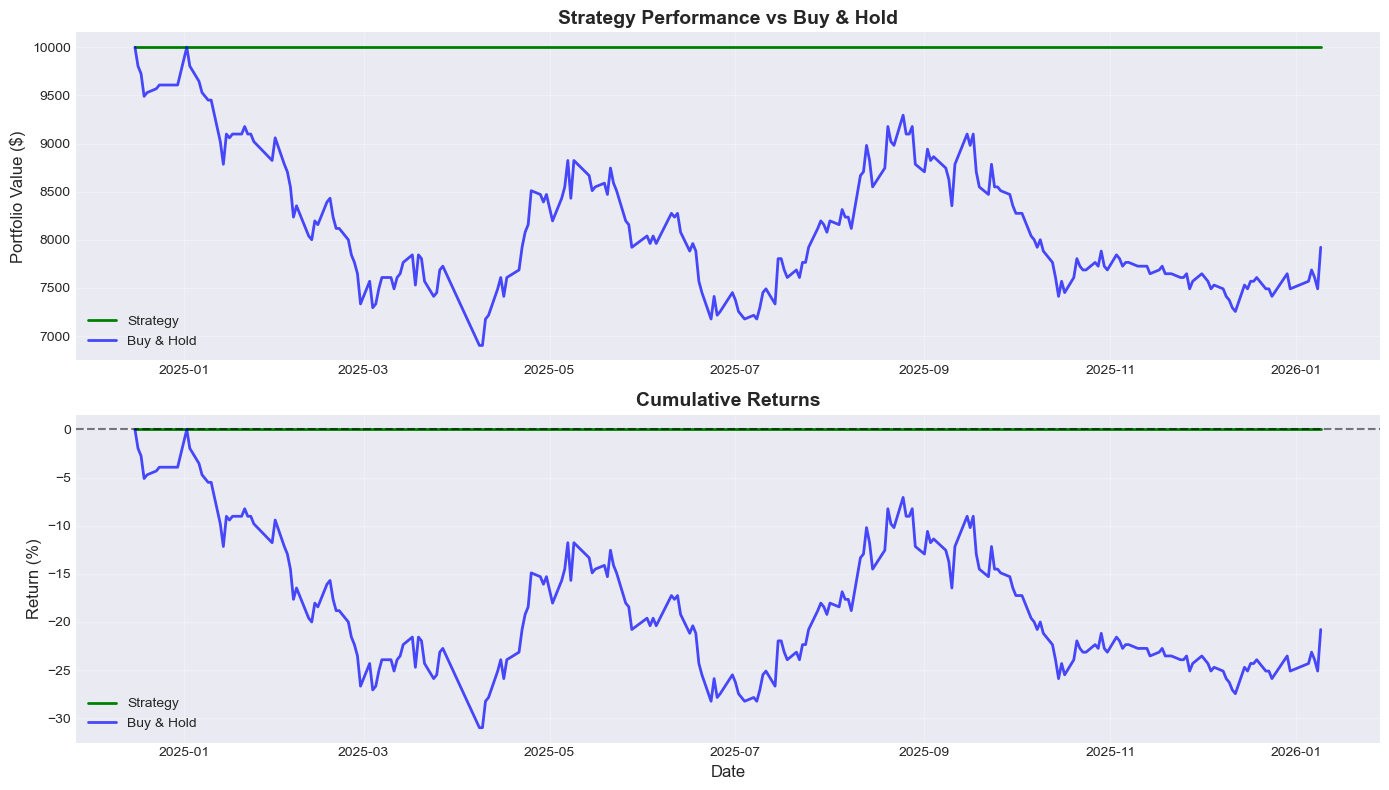

In [11]:
# Simple backtest simulation
def backtest_strategy(df, initial_capital=10000):
    """Simple backtest of the strategy"""
    df = df.copy()
    
    position = 0  # 0 = no position, 1 = long
    capital = initial_capital
    shares = 0
    trades = []
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        # Entry logic
        if position == 0 and row['final_signal'] in ['BUY', 'STRONG_BUY']:
            # Buy
            shares = capital / row['Close']
            position = 1
            trades.append({
                'date': row.name,
                'action': 'BUY',
                'price': row['Close'],
                'shares': shares,
                'value': capital
            })
        
        # Exit logic
        elif position == 1 and row['final_signal'] == 'SELL':
            # Sell
            capital = shares * row['Close']
            trades.append({
                'date': row.name,
                'action': 'SELL',
                'price': row['Close'],
                'shares': shares,
                'value': capital
            })
            position = 0
            shares = 0
    
    # Close any open position
    if position == 1:
        capital = shares * df.iloc[-1]['Close']
    
    # Calculate metrics
    total_return = (capital - initial_capital) / initial_capital * 100
    buy_hold_return = (df.iloc[-1]['Close'] - df.iloc[0]['Close']) / df.iloc[0]['Close'] * 100
    
    return {
        'final_capital': capital,
        'total_return': total_return,
        'buy_hold_return': buy_hold_return,
        'num_trades': len(trades),
        'trades': trades
    }

# Run backtest on test period
test_data = df_final.iloc[split_idx:]
results = backtest_strategy(test_data, initial_capital=10000)

print(f"\n{'='*80}")
print("BACKTEST RESULTS (Test Period)")
print(f"{'='*80}\n")

print(f"Initial Capital: ${10000:,.2f}")
print(f"Final Capital: ${results['final_capital']:,.2f}")
print(f"\n📊 Strategy Return: {results['total_return']:.2f}%")
print(f"📊 Buy & Hold Return: {results['buy_hold_return']:.2f}%")
print(f"📊 Outperformance: {results['total_return'] - results['buy_hold_return']:.2f}%")
print(f"\n🔄 Number of Trades: {results['num_trades']}")

if results['num_trades'] > 0:
    print(f"\n📋 Recent Trades:")
    trades_df = pd.DataFrame(results['trades'])
    print(trades_df.tail(10).to_string(index=False))

# Performance visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Portfolio value over time
portfolio_value = [10000]
position = 0
shares = 0
capital = 10000

for i in range(len(test_data)):
    row = test_data.iloc[i]
    
    if position == 0 and row['final_signal'] in ['BUY', 'STRONG_BUY']:
        shares = capital / row['Close']
        position = 1
    elif position == 1 and row['final_signal'] == 'SELL':
        capital = shares * row['Close']
        position = 0
        shares = 0
    
    current_value = capital if position == 0 else shares * row['Close']
    portfolio_value.append(current_value)

portfolio_value = portfolio_value[:-1]  # Remove last extra value

ax1.plot(test_data.index, portfolio_value, label='Strategy', linewidth=2, color='green')
buy_hold_value = 10000 * (test_data['Close'] / test_data['Close'].iloc[0])
ax1.plot(test_data.index, buy_hold_value, label='Buy & Hold', linewidth=2, color='blue', alpha=0.7)
ax1.set_title('Strategy Performance vs Buy & Hold', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative returns
strategy_returns = np.array(portfolio_value) / 10000 - 1
buyhold_returns = buy_hold_value.values / 10000 - 1

ax2.plot(test_data.index, strategy_returns * 100, label='Strategy', linewidth=2, color='green')
ax2.plot(test_data.index, buyhold_returns * 100, label='Buy & Hold', linewidth=2, color='blue', alpha=0.7)
ax2.axhline(0, linestyle='--', color='black', alpha=0.5)
ax2.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
ax2.set_ylabel('Return (%)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

try:
    plt.savefig('strategy_performance.png', dpi=150, bbox_inches='tight')
    print("\n💾 Performance chart saved as 'strategy_performance.png'")
except Exception as e:
    print(f"\n⚠️ Could not save chart: {e}")

plt.show()

## 9. Export Signals for Trading

In [12]:
# Export recent signals to CSV
export_cols = [
    'Close', 'final_signal', 'confidence', 'signal_strength',
    'technical_signal', 'rsi', 'macd', 'macd_signal', 'adx',
    'sma_20', 'sma_50', 'bb_middle', 'bb_upper', 'bb_lower'
]

# Add forecasts
for h in config.forecast_horizons:
    export_cols.append(f'forecast_{h}')

export_df = df_final[export_cols].tail(60)  # Last 60 days

try:
    filename = f'trading_signals_{config.ticker}_{datetime.now().strftime("%Y%m%d")}.csv'
    export_df.to_csv(filename)
    print(f"\n💾 Trading signals exported to: {filename}")
    print(f"   - Contains last 60 days of data")
    print(f"   - Columns: {len(export_cols)}")
except Exception as e:
    print(f"\n⚠️ Could not export CSV: {e}")

print(f"\n✅ Analysis Complete!")
print(f"\n{'='*80}")
print("SYSTEM SUMMARY")
print(f"{'='*80}")
print(f"✓ ML forecasting models trained for {len(config.forecast_horizons)} horizons")
print(f"✓ Technical indicators calculated: RSI, MACD, BB, ADX, OBV")
print(f"✓ Combined strategy signals generated")
print(f"✓ Backtest completed with {results['num_trades']} trades")
print(f"✓ Performance: {results['total_return']:.2f}% vs Buy&Hold {results['buy_hold_return']:.2f}%")
print(f"\n🎯 Current Recommendation: {latest['final_signal']} (Confidence: {latest['confidence']:.1f}%)")


💾 Trading signals exported to: trading_signals_SMRA.JK_20260209.csv
   - Contains last 60 days of data
   - Columns: 17

✅ Analysis Complete!

SYSTEM SUMMARY
✓ ML forecasting models trained for 3 horizons
✓ Technical indicators calculated: RSI, MACD, BB, ADX, OBV
✓ Combined strategy signals generated
✓ Backtest completed with 0 trades
✓ Performance: 0.00% vs Buy&Hold -20.78%

🎯 Current Recommendation: HOLD (Confidence: 70.2%)


## 10. Fundamental Analysis

Adding fundamental metrics to complement technical analysis and ML forecasting.

In [13]:
import yfinance as yf
import pandas as pd

class FundamentalAnalyzer:
    """Analyzes fundamental financial metrics"""
    
    def __init__(self, ticker: str):
        self.ticker = ticker
        self.stock = yf.Ticker(ticker)
        self.info = self.stock.info
    
    @staticmethod
    def safe_format(value, fmt=".2f", pct=False, comma=False):
        """Gracefully format numbers even when None."""
        if value is None:
            return "N/A"
        try:
            if pct:
                return f"{value:{fmt}%}"
            elif comma:
                return f"{value:,.0f}"
            else:
                return f"{value:{fmt}}"
        except Exception:
            return "N/A"
    
    def get_financial_ratios(self):
        """Extract key financial ratios"""
        return {
            'P/E Ratio': self.info.get('forwardPE') or self.info.get('trailingPE'),
            'P/B Ratio': self.info.get('priceToBook'),
            'PEG Ratio': self.info.get('pegRatio'),
            'Debt/Equity': self.info.get('debtToEquity'),
            'Current Ratio': self.info.get('currentRatio'),
            'Quick Ratio': self.info.get('quickRatio'),
            'ROE': self.info.get('returnOnEquity'),
            'ROA': self.info.get('returnOnAssets'),
            'Profit Margin': self.info.get('profitMargins'),
            'Operating Margin': self.info.get('operatingMargins'),
            'Market Cap': self.info.get('marketCap'),
            'Enterprise Value': self.info.get('enterpriseValue'),
            'Dividend Yield': self.info.get('dividendYield'),
            'Beta': self.info.get('beta'),
            '52W High': self.info.get('fiftyTwoWeekHigh'),
            '52W Low': self.info.get('fiftyTwoWeekLow'),
        }
    
    def display_analysis(self):
        """Display complete fundamental analysis"""
        print(f"\n{'='*80}")
        print(f"📊 FUNDAMENTAL ANALYSIS: {self.ticker}")
        print(f"{'='*80}\n")
        
        # Company info
        print(f"Company: {self.info.get('longName', 'N/A')}")
        print(f"Sector: {self.info.get('sector', 'N/A')}")
        print(f"Industry: {self.info.get('industry', 'N/A')}")
        print(f"Country: {self.info.get('country', 'N/A')}")
        
        # Financial ratios
        ratios = self.get_financial_ratios()
        
        print(f"\n--- Valuation Metrics ---")
        print(f"P/E Ratio: {self.safe_format(ratios['P/E Ratio'])}")
        print(f"P/B Ratio: {self.safe_format(ratios['P/B Ratio'])}")
        print(f"PEG Ratio: {self.safe_format(ratios['PEG Ratio'])}")
        print(f"Market Cap: {self.safe_format(ratios['Market Cap'], comma=True)}")
        print(f"Enterprise Value: {self.safe_format(ratios['Enterprise Value'], comma=True)}")
        
        print(f"\n--- Profitability Metrics ---")
        print(f"ROE: {self.safe_format(ratios['ROE'], '.2', pct=True)}")
        print(f"ROA: {self.safe_format(ratios['ROA'], '.2', pct=True)}")
        print(f"Profit Margin: {self.safe_format(ratios['Profit Margin'], '.2', pct=True)}")
        print(f"Operating Margin: {self.safe_format(ratios['Operating Margin'], '.2', pct=True)}")
        
        print(f"\n--- Financial Health ---")
        print(f"Debt/Equity: {self.safe_format(ratios['Debt/Equity'])}")
        print(f"Current Ratio: {self.safe_format(ratios['Current Ratio'])}")
        print(f"Quick Ratio: {self.safe_format(ratios['Quick Ratio'])}")
        
        print(f"\n--- Market Metrics ---")
        print(f"Beta: {self.safe_format(ratios['Beta'])}")
        print(f"Dividend Yield: {self.safe_format(ratios['Dividend Yield'], '.2', pct=True)}")
        print(f"52W High: {self.safe_format(ratios['52W High'])}")
        print(f"52W Low: {self.safe_format(ratios['52W Low'])}")
        
        # Summary table
        summary_data = [
            ("P/E Ratio", self.safe_format(ratios['P/E Ratio'])),
            ("P/B Ratio", self.safe_format(ratios['P/B Ratio'])),
            ("Debt/Equity", self.safe_format(ratios['Debt/Equity'])),
            ("ROE", self.safe_format(ratios['ROE'], '.2', pct=True)),
            ("Market Cap", self.safe_format(ratios['Market Cap'], comma=True)),
        ]
        
        summary_df = pd.DataFrame(summary_data, columns=["Metric", "Value"])
        print(f"\n--- Quick Summary ---")
        print(summary_df.to_string(index=False))
        
        # Financial statements
        try:
            print(f"\n--- Latest Income Statement (first 5 rows) ---")
            income_stmt = self.stock.income_stmt
            if not income_stmt.empty:
                print(income_stmt.head())
        except Exception as e:
            print(f"Could not retrieve income statement: {e}")
        
        return ratios

# Run fundamental analysis
print("\n" + "="*80)
print("ADDING FUNDAMENTAL ANALYSIS TO COMPLETE THE PICTURE")
print("="*80)

fundamental = FundamentalAnalyzer(config.ticker)
fund_ratios = fundamental.display_analysis()

# Combine with technical recommendation
print(f"\n{'='*80}")
print("HOLISTIC TRADING DECISION")
print(f"{'='*80}\n")

print("✅ Technical + ML Signal:", latest['final_signal'])
print(f"✅ Confidence: {latest['confidence']:.1f}%")
print(f"\n📊 Fundamental Quality Check:")

# Simple fundamental scoring
fund_score = 0
reasons = []

if fund_ratios['P/E Ratio'] and fund_ratios['P/E Ratio'] < 15:
    fund_score += 1
    reasons.append("+ Low P/E ratio (undervalued)")
elif fund_ratios['P/E Ratio'] and fund_ratios['P/E Ratio'] > 30:
    fund_score -= 1
    reasons.append("- High P/E ratio (potentially overvalued)")

if fund_ratios['ROE'] and fund_ratios['ROE'] > 0.15:
    fund_score += 1
    reasons.append("+ Strong ROE (>15%)")

if fund_ratios['Debt/Equity'] and fund_ratios['Debt/Equity'] < 1:
    fund_score += 1
    reasons.append("+ Low debt levels")
elif fund_ratios['Debt/Equity'] and fund_ratios['Debt/Equity'] > 2:
    fund_score -= 1
    reasons.append("- High debt levels")

if fund_ratios['Current Ratio'] and fund_ratios['Current Ratio'] > 1.5:
    fund_score += 1
    reasons.append("+ Good liquidity")

for reason in reasons:
    print(f"   {reason}")

print(f"\n📈 Fundamental Score: {fund_score}/4")

if fund_score >= 2:
    print("✅ Fundamentals support the trade")
elif fund_score >= 0:
    print("⚠️ Neutral fundamentals - proceed with caution")
else:
    print("❌ Weak fundamentals - higher risk")

print(f"\n💡 FINAL RECOMMENDATION:")
if latest['final_signal'] in ['BUY', 'STRONG_BUY'] and fund_score >= 1:
    print("   ✅ STRONG BUY - Both technical and fundamental signals align")
elif latest['final_signal'] in ['BUY', 'STRONG_BUY']:
    print("   ⚠️ CAUTIOUS BUY - Technical signals positive but fundamentals weak")
elif latest['final_signal'] == 'SELL' or fund_score < 0:
    print("   ❌ SELL or AVOID - Risk factors present")
else:
    print("   ⏸️ HOLD - Wait for better opportunity")


ADDING FUNDAMENTAL ANALYSIS TO COMPLETE THE PICTURE

📊 FUNDAMENTAL ANALYSIS: SMRA.JK

Company: PT Summarecon Agung Tbk
Sector: Real Estate
Industry: Real Estate - Development
Country: Indonesia

--- Valuation Metrics ---
P/E Ratio: 6.90
P/B Ratio: 0.57
PEG Ratio: N/A
Market Cap: 6,471,359,135,744
Enterprise Value: 18,980,171,415,552

--- Profitability Metrics ---
ROE: 10.44%
ROA: 5.07%
Profit Margin: 10.37%
Operating Margin: 29.28%

--- Financial Health ---
Debt/Equity: 81.56
Current Ratio: 1.10
Quick Ratio: 0.25

--- Market Metrics ---
Beta: 0.50
Dividend Yield: 232.00%
52W High: 488.00
52W Low: 340.00

--- Quick Summary ---
     Metric             Value
  P/E Ratio              6.90
  P/B Ratio              0.57
Debt/Equity             81.56
        ROE            10.44%
 Market Cap 6,471,359,135,744

--- Latest Income Statement (first 5 rows) ---
                                          2024-12-31    2023-12-31  \
Tax Effect Of Unusual Items            -5.038914e+09 -5.985372e+06 